<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 700; line-height: 1.2;">
        Análisis de Fechas y Datos Inconsistentes
      </h1>
      <p style="margin: 6px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Programación para Ciencia de Datos
      </p>
    </td>
    <td style="vertical-align: middle; text-align: right; border: none; padding: 15px 20px; min-width: 240px; font-family: system-ui, -apple-system, sans-serif;">
      <div style="font-size: 0.9em; color: #334155; line-height: 1.5;">
        <strong style="color: #1e3a8a; font-size: 1em;">Especialización en Ciencia de Datos</strong><br>
        <span style="color: #475569; font-weight: 600;">USTA Tunja</span><br><br>
        <b>Santiago A. Zúñiga M.</b><br>
        ✉️ <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
      </div>
    </td>
  </tr>
</table>

---
## Introducción

En este cuaderno abordaremos dos problemas muy frecuentes en el preprocesamiento de datos reales:

1. **🗓️ Análisis de Fechas (Parsing Dates):** Las fechas son uno de los tipos de datos más comunes y también de los más complicados. Python puede no reconocer automáticamente que una cadena de texto como `"3/2/07"` es una fecha, lo que nos impide hacer operaciones temporales como extraer el mes, calcular diferencias entre fechas o graficar series de tiempo correctamente.

2. **🧗 Datos Inconsistentes (Inconsistent Data Entry):** En conjuntos de datos reales, los mismos valores pueden estar escritos de formas diferentes: `"south korea"` y `"southkorea"`, `"Germany"` y `" germany"`. Esta inconsistencia genera duplicados invisibles que pueden sesgar análisis y modelos.

Trabajaremos con dos datasets:
- **Dataset de Deslizamientos de Tierra** (`landslide-events.csv`): para practicar el análisis de fechas.
- **Dataset de Capital Intelectual de Pakistán** (`pakistan_intellectual_capital.csv`): para practicar la corrección de datos inconsistentes.

---
### Configuración del Entorno 🛠️

Lo primero que necesitamos hacer es cargar las librerías necesarias. Usaremos `fuzzywuzzy` para la coincidencia difusa de texto (*fuzzy matching*).

In [1]:
!pip install fuzzywuzzy

In [2]:
# Módulos base
import pandas as pd
import numpy as np

# Módulos de visualización
import seaborn as sns
import matplotlib.pyplot as plt

# Módulos útiles para la limpieza de entrada de datos (Inconsistent data entry)
import fuzzywuzzy
from fuzzywuzzy import process

# Fijamos la semilla aleatoria para que los resultados sean reproducibles
np.random.seed(0)

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


/usr/local/lib/python3.13/dist-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


> ⚠️ *Nota: Si te encuentras con un error de `ModuleNotFoundError` en un entorno local, puedes instalar paquetes faltantes usando: `!pip install fuzzywuzzy` en una celda de código.*

---
### Parte 1: 🗓️ Análisis de Fechas (Parsing Dates)



---
####  Cargando los Datos de Deslizamientos de Tierra 🔍

Para la primera parte trabajaremos con el **[Dataset de Deslizamientos de Tierra](https://www.kaggle.com/datasets/nasa/landslide-events)**, que contiene información sobre deslizamientos ocurridos entre 2007 y 2016 alrededor del mundo.

In [3]:
import os
import urllib.request

# --- Resolución de Rutas y Fallback ---
file_path = 'data/landslide-events.csv'
if not os.path.exists(file_path) and os.path.exists(f'05 - Data Preparation/{file_path}'):
    file_path = f'05 - Data Preparation/{file_path}'

if not os.path.exists(file_path):
    print('Descargando dataset...')
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    url = 'https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/05%20-%20Data%20Preparation/data/landslide-events.csv'
    urllib.request.urlretrieve(url, file_path)
# --------------------------------------

# Leemos los datos
landslides = pd.read_csv(file_path)

print(f"Dataset cargado: {landslides.shape[0]} filas × {landslides.shape[1]} columnas")
landslides.head()

Dataset cargado: 1693 filas × 23 columnas


,id,date,time,continent_code,country_name,country_code,state/province,population,city/town,distance,...,geolocation,hazard_type,landslide_type,landslide_size,trigger,storm_name,injuries,fatalities,source_name,source_link
0,34,3/2/07,Night,NaN,United States,US,Virginia,16000,Cherry Hill,3.40765,...,"(38.600900000000003, -77.268199999999993)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,NBC 4 news,http://www.nbc4.com/news/11186871/detail.html
1,42,3/22/07,NaN,NaN,United States,US,Ohio,17288,New Philadelphia,3.33522,...,"(40.517499999999998, -81.430499999999995)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,Canton Rep.com,http://www.cantonrep.com/index.php?ID=345054&C...
2,56,4/6/07,NaN,NaN,United States,US,Pennsylvania,15930,Wilkinsburg,2.91977,...,"(40.4377, -79.915999999999997)",Landslide,Landslide,Small,Rain,NaN,NaN,NaN,The Pittsburgh Channel.com,https://web.archive.org/web/20080423132842/htt...
3,59,4/14/07,NaN,NaN,Canada,CA,Quebec,42786,Châteauguay,2.98682,...,"(45.322600000000001, -73.777100000000004)",Landslide,Riverbank collapse,Small,Rain,NaN,NaN,NaN,Le Soleil,http://www.hebdos.net/lsc/edition162007/articl...
4,61,4/15/07,NaN,NaN,United States,US,Kentucky,6903,Pikeville,5.66542,...,"(37.432499999999997, -82.493099999999998)",Landslide,Landslide,Small,Downpour,NaN,NaN,0.0,Matthew Crawford (KGS),NaN


---
#### Verificar el Tipo de Dato de la Columna de Fecha 🔍

Trabajaremos con la columna `"date"`. El primer paso es verificar que Python la esté interpretando como una fecha y no como texto plano.

In [4]:
# Revisamos los primeros valores de la columna 'date'
print("Primeros valores de la columna 'date':")
print(landslides['date'].head())

# Verificamos el tipo de dato de la columna
print(f"\nTipo de dato de la columna 'date': {landslides['date'].dtype}")

Primeros valores de la columna 'date':
0     3/2/07
1    3/22/07
2     4/6/07
3    4/14/07
4    4/15/07
Name: date, dtype: object

Tipo de dato de la columna 'date': object


Los valores como `3/2/07` son fechas para un humano, pero para Python son simplemente **texto** (`object`/`O`). Esto significa que no podemos hacer operaciones temporales sobre ellos.

Pandas usa el dtype **`object`** para almacenar texto (strings). El tipo correcto para fechas es **`datetime64`**. Podemos comprobarlo:

```python
# dtype 'O' = object (texto)
landslides['date'].dtype  # dtype('O')
```

Puedes consultar la [documentación de dtypes de NumPy](https://docs.scipy.org/doc/numpy-1.12.0/reference/generated/numpy.dtype.kind.html#numpy.dtype.kind) para ver a qué corresponde cada letra.

---
#### Convertir la Columna de Fechas a `datetime` 🗓️

Ahora convertiremos la columna de fechas al tipo `datetime64`. Este proceso se denomina **"parsing de fechas"** — tomar una cadena de texto e identificar sus partes (año, mes, día).

Para indicarle a `pd.to_datetime()` el formato correcto, usamos la [guía de directivas `strftime`](http://strftime.org/). Los códigos más comunes son:

| Código | Significado | Ejemplo |
|--------|-------------|---------|
| `%d` | Día del mes (01–31) | `02`, `14` |
| `%m` | Mes (01–12) | `03`, `12` |
| `%y` | Año con 2 dígitos | `07` → 2007 |
| `%Y` | Año con 4 dígitos | `2007` |

**Ejemplos de formatos:**
- `1/17/07` → formato `"%m/%d/%y"`
- `17-1-2007` → formato `"%d-%m-%Y"`

Mirando nuestra columna `date`, los valores tienen el formato `mes/día/año-2-dígitos` (ej. `3/2/07`), entonces usaremos `"%m/%d/%y"`.

In [5]:
# Creamos una nueva columna 'date_parsed' con las fechas parseadas correctamente
landslides['date_parsed'] = pd.to_datetime(landslides['date'], format="%m/%d/%y")

# Revisamos los primeros valores de la nueva columna
print("Columna 'date_parsed' convertida a datetime64:")
print(landslides['date_parsed'].head())
print(f"\nTipo de dato: {landslides['date_parsed'].dtype}")

Columna 'date_parsed' convertida a datetime64:
0   2007-03-02
1   2007-03-22
2   2007-04-06
3   2007-04-14
4   2007-04-15
Name: date_parsed, dtype: datetime64[ns]

Tipo de dato: datetime64[ns]


> 💡 **¿Qué pasa si hay múltiples formatos de fecha en una misma columna?**
>
> Puedes pedirle a pandas que **infiera** el formato automáticamente:
> ```python
> landslides['date_parsed'] = pd.to_datetime(landslides['date'], infer_datetime_format=True)
> ```
> **¿Por qué no usar siempre `infer_datetime_format=True`?**
> - Pandas puede equivocarse si hay formatos creativos o ambiguos (¿`01/02/03` es enero-2 o febrero-1?).
> - Es **significativamente más lento** que especificar el formato exacto.

---
##### 🛠️ Práctica 1: Verificando el Parsing de Fechas

---

Usando el dataframe `landslides` ya cargado:

1. Imprime el **tipo de dato** (`dtype`) de la columna `'date'` (original, texto) y de `'date_parsed'` (convertida).
2. Usando la columna `'date_parsed'`, extrae el **año** de cada registro con el atributo `.dt.year` y guárdalo en una variable `year_landslides`.
3. Imprime los primeros 5 valores de `year_landslides`.

> *Pista: Todos los valores deben estar entre 2007 y 2016.*

In [6]:
# Escribe tu código aquí


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
# 1. Tipos de dato
print(f"Tipo de 'date' (original): {landslides['date'].dtype}")
print(f"Tipo de 'date_parsed':     {landslides['date_parsed'].dtype}")

# 2. Extraer el año
year_landslides = landslides['date_parsed'].dt.year

# 3. Primeros 5 valores
print("\nPrimeros 5 años:")
print(year_landslides.head())
```
</details>

---

---
####  Extraer el Día del Mes 📅

Una vez que la columna está en formato `datetime64`, podemos extraer cualquier componente de la fecha con el **accesor `.dt`**:

| Atributo | Descripción |
|---|---|
| `.dt.day` | Día del mes (1–31) |
| `.dt.month` | Número de mes (1–12) |
| `.dt.year` | Año (4 dígitos) |
| `.dt.day_of_week` | Día de la semana (0=Lunes, 6=Domingo) |
| `.dt.hour` | Hora |

Extraigamos el día del mes en que ocurrió cada deslizamiento:

In [7]:
# Extraemos el día del mes desde la columna 'date_parsed'
day_of_month_landslides = landslides['date_parsed'].dt.day

print("Día del mes de los primeros registros:")
print(day_of_month_landslides.head())
print(f"\nTipo de dato: {day_of_month_landslides.dtype}")

Día del mes de los primeros registros:
0     2.0
1    22.0
2     6.0
3    14.0
4    15.0
Name: date_parsed, dtype: float64

Tipo de dato: float64


Nota que si intentáramos hacer lo mismo con la columna **original** (texto `object`), obtendríamos un error:

```python
# Esto generaría un AttributeError
landslides['date'].dt.day
# AttributeError: Can only use .dt accessor with datetimelike values
```

Este error ocurre porque `.dt.day` no sabe cómo procesar una columna de tipo `object`. Por eso es fundamental **convertir primero** las fechas al tipo correcto.

---
####  Verificar el Parsing con un Histograma 📊

Una de las **trampas más comunes** al parsear fechas es confundir el mes con el día. Por ejemplo, `pd.to_datetime("3/2/07", format="%d/%m/%y")` interpretaría el 3 como el **día** y el 2 como el **mes**, cuando en realidad es al revés.

Para verificar que nuestro parsing fue correcto, graficamos un **histograma del día del mes**. Esperamos:
- Valores entre **1 y 31** (días del mes).
- Una distribución **relativamente uniforme** (los deslizamientos no tienen preferencia por un día específico).
- Una pequeña disminución alrededor del día 31 (no todos los meses tienen 31 días).

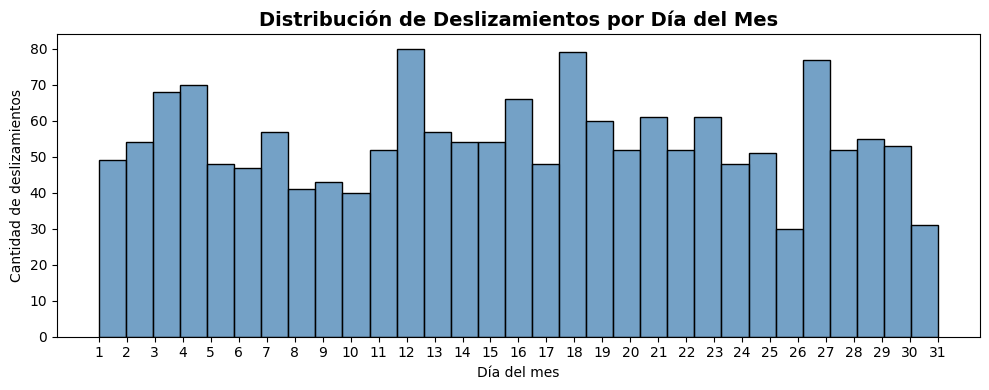


Min día: 1 | Max día: 31
✅ Los valores están entre 1 y 31 — ¡el parsing fue correcto!


In [8]:
# Eliminamos los valores nulos antes de graficar
day_of_month_landslides = day_of_month_landslides.dropna()

# Graficamos el histograma del día del mes
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(day_of_month_landslides, bins=31, kde=False, color='steelblue', ax=ax)
ax.set_title("Distribución de Deslizamientos por Día del Mes", fontsize=14, fontweight='bold')
ax.set_xlabel("Día del mes")
ax.set_ylabel("Cantidad de deslizamientos")
ax.set_xticks(range(1, 32))
plt.tight_layout()
plt.show()

print(f"\nMin día: {day_of_month_landslides.min():.0f} | Max día: {day_of_month_landslides.max():.0f}")
print("✅ Los valores están entre 1 y 31 — ¡el parsing fue correcto!")

---
##### 🛠️ Práctica 2: Análisis Temporal de Deslizamientos

---

Usando el dataframe `landslides` y la columna `'date_parsed'`:

1. Extrae el **mes** de cada deslizamiento y guárdalo en `month_landslides`. Elimina los valores nulos.
2. Grafica un **histograma** del mes (similar al del día del mes). Usa `bins=12` (uno por mes) y un color diferente.
3. ¿En qué meses del año ocurren más deslizamientos? ¿Puedes intuir una razón?

> *Pista: Usa `.dt.month` y `sns.histplot()` con `bins=12`.*

In [9]:
# Escribe tu código aquí


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
# 1. Extraer el mes y eliminar nulos
month_landslides = landslides['date_parsed'].dt.month.dropna()

# 2. Histograma de meses
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(month_landslides, bins=12, kde=False, color='salmon', ax=ax)
ax.set_title("Distribución de Deslizamientos por Mes del Año", fontsize=14, fontweight='bold')
ax.set_xlabel("Mes (1=Enero, 12=Diciembre)")
ax.set_ylabel("Cantidad de deslizamientos")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

# 3. Meses con más deslizamientos
print("Top 3 meses con más deslizamientos:")
print(month_landslides.value_counts().head(3))
print("\n💡 Los meses lluviosos (mayo-octubre) tienden a tener más deslizamientos.")
```
</details>

---

---
#### Diferentes Formatos de Fecha 🔄

En la práctica, te encontrarás con fechas en muchos formatos distintos. Aquí tienes ejemplos de cómo parsear los más comunes:

| Fecha de ejemplo | Formato `strftime` | Código |
|---|---|---|
| `3/2/07` | mes/día/año-2d | `"%m/%d/%y"` |
| `2007-03-02` | año-mes-día | `"%Y-%m-%d"` |
| `02/03/2007` | día/mes/año-4d | `"%d/%m/%Y"` |
| `March 2, 2007` | Mes-texto día, año | `"%B %d, %Y"` |
| `02-Mar-07` | día-mes-abrev-año-2d | `"%d-%b-%y"` |

In [10]:
# Demostración de distintos formatos de fecha
ejemplos = pd.DataFrame({
    'formato_slash_mes_dia_año2d': ['3/2/07', '12/25/21', '1/1/20'],
    'formato_iso':                 ['2007-03-02', '2021-12-25', '2020-01-01'],
    'formato_texto':               ['March 2, 2007', 'December 25, 2021', 'January 1, 2020']
})

# Parseamos cada columna con su formato correspondiente
ejemplos['parsed_slash']  = pd.to_datetime(ejemplos['formato_slash_mes_dia_año2d'], format='%m/%d/%y')
ejemplos['parsed_iso']    = pd.to_datetime(ejemplos['formato_iso'],                 format='%Y-%m-%d')
ejemplos['parsed_texto']  = pd.to_datetime(ejemplos['formato_texto'],               format='%B %d, %Y')

print("Fechas parseadas desde diferentes formatos:")
display(ejemplos[['formato_slash_mes_dia_año2d', 'formato_iso', 'formato_texto',
                   'parsed_slash', 'parsed_iso', 'parsed_texto']])

Fechas parseadas desde diferentes formatos:


,formato_slash_mes_dia_año2d,formato_iso,formato_texto,parsed_slash,parsed_iso,parsed_texto
0,3/2/07,2007-03-02,"March 2, 2007",2007-03-02,2007-03-02,2007-03-02
1,12/25/21,2021-12-25,"December 25, 2021",2021-12-25,2021-12-25,2021-12-25
2,1/1/20,2020-01-01,"January 1, 2020",2020-01-01,2020-01-01,2020-01-01


---
---
### Parte 2: 🧗 Datos Inconsistentes (Inconsistent Data Entry)



---
####  Cargando los Datos de Capital Intelectual 🔍

Para la segunda parte trabajaremos con el **Dataset de Capital Intelectual de Pakistán**, que contiene información sobre profesores universitarios. El problema que resolveremos es que los nombres de países en la columna `Country` fueron ingresados de formas inconsistentes.

In [11]:
# --- Resolución de Rutas y Fallback ---
file_path_prof = 'data/pakistan_intellectual_capital.csv'
if not os.path.exists(file_path_prof) and os.path.exists(f'05 - Data Preparation/{file_path_prof}'):
    file_path_prof = f'05 - Data Preparation/{file_path_prof}'

if not os.path.exists(file_path_prof):
    print('Descargando dataset...')
    url_prof = 'https://raw.githubusercontent.com/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/main/05%20-%20Data%20Preparation/data/pakistan_intellectual_capital.csv'
    urllib.request.urlretrieve(url_prof, file_path_prof)
# --------------------------------------

professors = pd.read_csv(file_path_prof)
print(f"Dataset cargado: {professors.shape[0]} filas × {professors.shape[1]} columnas")
professors.head()

Dataset cargado: 1142 filas × 13 columnas


,Unnamed: 0,S#,Teacher Name,University Currently Teaching,Department,Province University Located,Designation,Terminal Degree,Graduated from,Country,Year,Area of Specialization/Research Interests,Other Information
0,2,3,Dr. Abdul Basit,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,Software Engineering & DBMS,NaN
1,4,5,Dr. Waheed Noor,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,DBMS,NaN
2,5,6,Dr. Junaid Baber,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,"Information processing, Multimedia mining",NaN
3,6,7,Dr. Maheen Bakhtyar,University of Balochistan,Computer Science & IT,Balochistan,Assistant Professor,PhD,Asian Institute of Technology,Thailand,NaN,"NLP, Information Retrieval, Question Answering...",NaN
4,24,25,Samina Azim,Sardar Bahadur Khan Women's University,Computer Science,Balochistan,Lecturer,BS,Balochistan University of Information Technolo...,Pakistan,2005.0,VLSI Electronics DLD Database,NaN


---
#### Identificar Inconsistencias en los Datos 🔎

Supongamos que estamos interesados en analizar la columna `Country`. El primer paso es mirar todos los valores únicos para detectar inconsistencias manualmente.

In [12]:
# Obtenemos todos los valores únicos en la columna 'Country'
countries = professors['Country'].unique()

# Los ordenamos alfabéticamente para verlos mejor
countries.sort()

print(f"Total de valores únicos en 'Country': {len(countries)}")
print("\nLista completa de países:")
print(countries)

Total de valores únicos en 'Country': 38

Lista completa de países:
[' Germany' ' New Zealand' ' Sweden' ' USA' 'Australia' 'Austria' 'Canada'
 'China' 'Finland' 'France' 'Greece' 'HongKong' 'Ireland' 'Italy' 'Japan'
 'Macau' 'Malaysia' 'Mauritius' 'Netherland' 'New Zealand' 'Norway'
 'Pakistan' 'Portugal' 'Russian Federation' 'Saudi Arabia' 'Scotland'
 'Singapore' 'South Korea' 'SouthKorea' 'Spain' 'Sweden' 'Thailand'
 'Turkey' 'UK' 'USA' 'USofA' 'Urbana' 'germany']


Mirando la lista, podemos ver varios tipos de inconsistencias:

| Problema | Ejemplos |
|---|---|
| **Espacios en blanco al inicio** | `' Germany'`, `' USA'`, `' New Zealand'` |
| **Capitalización diferente** | `'germany'` vs `'Germany'` |
| **Palabras unidas vs separadas** | `'SouthKorea'` vs `'South Korea'` |
| **Abreviaciones no estándar** | `'USofA'` en lugar de `'USA'` |

La buena noticia es que podemos corregir la mayoría de estos problemas de forma **sistemática y automática**.

---
#### Corrección Básica: Minúsculas y Espacios 🧹

El primer paso es siempre el más sencillo: convertir todo a **minúsculas** y eliminar los **espacios en blanco** al inicio y al final de las cadenas. Esto resuelve aproximadamente el **80%** de los problemas de inconsistencia en datos de texto.

In [13]:
# Convertimos a minúsculas
professors['Country'] = professors['Country'].str.lower()

# Eliminamos espacios al inicio y al final de cada valor
professors['Country'] = professors['Country'].str.strip()

# Verificamos los valores únicos nuevamente
countries = professors['Country'].unique()
countries.sort()

print(f"Valores únicos DESPUÉS de la limpieza básica: {len(countries)}")
print("\nPaíses (post limpieza básica):")
print(countries)

Valores únicos DESPUÉS de la limpieza básica: 34

Países (post limpieza básica):
['australia' 'austria' 'canada' 'china' 'finland' 'france' 'germany'
 'greece' 'hongkong' 'ireland' 'italy' 'japan' 'macau' 'malaysia'
 'mauritius' 'netherland' 'new zealand' 'norway' 'pakistan' 'portugal'
 'russian federation' 'saudi arabia' 'scotland' 'singapore' 'south korea'
 'southkorea' 'spain' 'sweden' 'thailand' 'turkey' 'uk' 'urbana' 'usa'
 'usofa']


---
##### 🛠️ Práctica 3: Limpieza Básica de Texto

---

Tienes la siguiente `pd.Series` con nombres de ciudades con problemas de capitalización y espacios:

```python
ciudades = pd.Series(['  Bogotá', 'MEDELLÍN', ' cali ', 'Barranquilla', 'bogotá', 'CALI  ', 'medellín'])
```

1. Aplica `.str.lower()` y `.str.strip()` para limpiar la serie.
2. Imprime la serie limpia.
3. ¿Cuántos valores únicos quedan después de la limpieza? (Usa `.nunique()`).

In [14]:
# Escribe tu código aquí


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
ciudades = pd.Series(['  Bogotá', 'MEDELLÍN', ' cali ', 'Barranquilla', 'bogotá', 'CALI  ', 'medellín'])

# Limpieza
ciudades_limpias = ciudades.str.lower().str.strip()

print("Serie limpia:")
print(ciudades_limpias)

print(f"\nValores únicos ANTES: {ciudades.nunique()}")
print(f"Valores únicos DESPUÉS: {ciudades_limpias.nunique()}")
```
</details>

---

---
#### Corrección Avanzada: Fuzzy Matching 🔍

Después de la limpieza básica, aún quedan inconsistencias como `'southkorea'` vs `'south korea'` o `'usofa'` vs `'usa'`. Para estos casos usamos la técnica de **Fuzzy Matching** (*coincidencia difusa*).

> **Fuzzy Matching:** Proceso de encontrar automáticamente cadenas de texto que son muy similares a una cadena objetivo. La similitud se mide por la **distancia de edición** — el número mínimo de caracteres que hay que cambiar para transformar una cadena en la otra.
>
> - `"apple"` y `"snapple"` → distancia 2 (agregar "s" y "n").
> - `"in"` y `"on"` → distancia 1 (cambiar "i" por "o").

La librería `fuzzywuzzy` retorna un **ratio de similitud** del 0 al 100 (100 = idénticas).

In [15]:
# Obtenemos los 10 países más similares a "south korea"
countries = professors['Country'].unique()
matches = fuzzywuzzy.process.extract(
    "south korea",
    countries,
    limit=10,
    scorer=fuzzywuzzy.fuzz.token_sort_ratio
)

print("Top 10 coincidencias más cercanas a 'south korea':")
for nombre, ratio in matches:
    barra = '█' * (ratio // 5)
    print(f"  {ratio:3d} | {barra:<20} | '{nombre}'")

Top 10 coincidencias más cercanas a 'south korea':
  100 | ████████████████████ | 'south korea'
   48 | █████████            | 'southkorea'
   43 | ████████             | 'saudi arabia'
   35 | ███████              | 'norway'
   33 | ██████               | 'ireland'
   32 | ██████               | 'portugal'
   30 | ██████               | 'singapore'
   29 | █████                | 'netherland'
   25 | █████                | 'usofa'
   25 | █████                | 'macau'


Podemos ver que `'southkorea'` tiene un ratio de ~48 (muy similar) y `'south korea'` tiene 100 (idéntico). Esto nos permite **automatizar la corrección**: reemplazamos todos los valores con ratio > 47 por `'south korea'`.

> 💡 **¿Por qué usamos `token_sort_ratio`?** Este scorer ordena las palabras antes de compararlas, lo que lo hace más robusto para casos como `'south korea'` vs `'korea south'`. El scorer `ratio` simple podría fallar aquí.

---
#### Función de Reemplazo por Fuzzy Matching ⚙️

Escribimos una función reutilizable que reemplaza automáticamente todas las cadenas similares por el valor correcto. Es buena práctica encapsular esta lógica en una función, especialmente si la necesitamos para múltiples columnas o múltiples valores.

In [16]:
def replace_matches_in_column(df, column, string_to_match, min_ratio=47):
    """
    Reemplaza en la columna 'column' del dataframe 'df' todos los valores
    que tengan un ratio de similitud >= min_ratio con 'string_to_match'.
    
    Parámetros:
    -----------
    df             : pd.DataFrame — El dataframe a modificar.
    column         : str          — Nombre de la columna a limpiar.
    string_to_match: str          — El valor 'correcto' de referencia.
    min_ratio      : int          — Umbral mínimo de similitud (0-100). Default: 47.
    """
    # Obtenemos todos los valores únicos de la columna
    strings = df[column].unique()
    
    # Buscamos las 10 cadenas más cercanas al valor objetivo
    matches = fuzzywuzzy.process.extract(
        string_to_match, strings, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio
    )
    
    # Filtramos solo las que superan el umbral
    close_matches = [match[0] for match in matches if match[1] >= min_ratio]
    
    # Reemplazamos esas filas con el valor correcto
    rows_with_matches = df[column].isin(close_matches)
    df.loc[rows_with_matches, column] = string_to_match
    
    print(f"✅ Listo! Se reemplazaron los valores: {close_matches} → '{string_to_match}'")

# Aplicamos la función para corregir 'south korea'
replace_matches_in_column(df=professors, column='Country', string_to_match="south korea")

✅ Listo! Se reemplazaron los valores: ['south korea', 'southkorea'] → 'south korea'


In [17]:
# Verificamos que el reemplazo funcionó
countries = professors['Country'].unique()
countries.sort()

print(f"Valores únicos en 'Country' después de la corrección: {len(countries)}")
print("\nLista de países:")
print(countries)

# Confirmación: ya no existe 'southkorea'
print(f"\n¿Existe 'southkorea'? {'southkorea' in countries}")
print(f"¿Existe 'south korea'? {'south korea' in countries}")

Valores únicos en 'Country' después de la corrección: 33

Lista de países:
['australia' 'austria' 'canada' 'china' 'finland' 'france' 'germany'
 'greece' 'hongkong' 'ireland' 'italy' 'japan' 'macau' 'malaysia'
 'mauritius' 'netherland' 'new zealand' 'norway' 'pakistan' 'portugal'
 'russian federation' 'saudi arabia' 'scotland' 'singapore' 'south korea'
 'spain' 'sweden' 'thailand' 'turkey' 'uk' 'urbana' 'usa' 'usofa']

¿Existe 'southkorea'? False
¿Existe 'south korea'? True


---
##### 🛠️ Práctica 4: Fuzzy Matching

---

Mirando la lista de países aún hay inconsistencias visibles: `'usofa'` y `'urbana'` deberían ser `'usa'`.

Usando la función `replace_matches_in_column()` que definimos:
1. Llama la función para corregir los valores similares a `"usa"` en la columna `'Country'` del dataframe `professors`. Usa `min_ratio=60`.
2. Verifica que `'usofa'` y `'urbana'` ya no aparezcan en la lista de países únicos.
3. Imprime el número total de países únicos antes y después de la corrección.

> *Pista: Primero corre el fuzzy matching manualmente con `fuzzywuzzy.process.extract("usa", countries, ...)` para ver los ratios y elegir bien el `min_ratio`.*

In [18]:
# Escribe tu código aquí


<details>
<summary><b>💡 Haz clic aquí para ver la solución</b></summary>

```python
# Primero, exploramos los ratios para 'usa'
countries_now = professors['Country'].unique()
matches_usa = fuzzywuzzy.process.extract(
    "usa", countries_now, limit=10, scorer=fuzzywuzzy.fuzz.token_sort_ratio
)
print("Matches para 'usa':")
for nombre, ratio in matches_usa:
    print(f"  {ratio:3d} | '{nombre}'")

# 'usofa' tiene ratio ~60 y 'urbana' ~36. Con min_ratio=45 capturamos 'usofa' pero no 'usa' (que es correcto).
total_antes = professors['Country'].nunique()

replace_matches_in_column(df=professors, column='Country', string_to_match="usa", min_ratio=45)

total_despues = professors['Country'].nunique()

countries_final = professors['Country'].unique()
countries_final.sort()
print(f"\nPaíses únicos ANTES: {total_antes}")
print(f"Países únicos DESPUÉS: {total_despues}")
print(f"¿Existe 'usofa'? {'usofa' in countries_final}")
print(f"¿Existe 'urbana'? {'urbana' in countries_final}")
```
</details>

---

---
####  Pipeline Completo de Limpieza de Texto 🔄

Ahora que conocemos ambas técnicas, aquí tienes un **flujo de trabajo recomendado** para limpiar columnas de texto con datos inconsistentes:

```
1. Minúsculas y strip    → str.lower().str.strip()
2. Revisar valores únicos → .unique() y .sort()
3. Fuzzy matching manual → fuzzywuzzy.process.extract() para identificar candidatos
4. Reemplazar con función → replace_matches_in_column()
5. Verificar resultado   → .unique() de nuevo
```

Apliquemos este pipeline completo a la columna `'Country'` para unificar todos los valores problemáticos restantes:

In [19]:
# Recargamos los datos para tener un estado limpio
professors_clean = pd.read_csv(file_path_prof)

# === PASO 1: Limpieza básica ===
professors_clean['Country'] = professors_clean['Country'].str.lower().str.strip()
print(f"Paso 1 — Valores únicos tras limpieza básica: {professors_clean['Country'].nunique()}")

# === PASO 2: Revisar los valores únicos ===
paises = professors_clean['Country'].unique()
paises.sort()
print(f"\nPaíses con posibles inconsistencias detectadas:")
print([p for p in paises if len(p.replace(' ', '')) <= 3 or p in ['southkorea', 'usofa', 'urbana']])

# === PASO 3 y 4: Correcciones con fuzzy matching ===
correcciones = [
    ("south korea", 47),   # corrige 'southkorea'
    ("usa",         45),   # corrige 'usofa'
    ("hong kong",   55),   # corrige 'hongkong'
]

for valor_correcto, ratio_min in correcciones:
    replace_matches_in_column(
        df=professors_clean, column='Country',
        string_to_match=valor_correcto, min_ratio=ratio_min
    )

# === PASO 5: Verificar ===
paises_final = professors_clean['Country'].unique()
paises_final.sort()
print(f"\nValores únicos FINALES: {len(paises_final)}")
print(paises_final)

Paso 1 — Valores únicos tras limpieza básica: 34

Países con posibles inconsistencias detectadas:
['southkorea', 'uk', 'urbana', 'usa', 'usofa']
✅ Listo! Se reemplazaron los valores: ['south korea', 'southkorea'] → 'south korea'
✅ Listo! Se reemplazaron los valores: ['usa', 'usofa', 'austria', 'australia', 'spain'] → 'usa'
✅ Listo! Se reemplazaron los valores: ['hongkong'] → 'hong kong'

Valores únicos FINALES: 29
['canada' 'china' 'finland' 'france' 'germany' 'greece' 'hong kong'
 'ireland' 'italy' 'japan' 'macau' 'malaysia' 'mauritius' 'netherland'
 'new zealand' 'norway' 'pakistan' 'portugal' 'russian federation'
 'saudi arabia' 'scotland' 'singapore' 'south korea' 'sweden' 'thailand'
 'turkey' 'uk' 'urbana' 'usa']


---
#### 14. Resumen 📋

#### 🗓️ Parsing de Fechas

| Paso | Acción | Código |
|---|---|---|
| **1** | Verificar el dtype de la columna | `df['fecha'].dtype` |
| **2** | Convertir con formato conocido | `pd.to_datetime(df['fecha'], format='%m/%d/%y')` |
| **3** | O inferir automáticamente (más lento) | `pd.to_datetime(df['fecha'], infer_datetime_format=True)` |
| **4** | Extraer componentes temporales | `.dt.day`, `.dt.month`, `.dt.year`, `.dt.day_of_week` |
| **5** | Validar con histograma | `sns.histplot(df['fecha_parseada'].dt.day)` |

#### 🧗 Datos Inconsistentes

| Paso | Acción | Código |
|---|---|---|
| **1** | Minúsculas y strip | `.str.lower().str.strip()` |
| **2** | Revisar únicos | `.unique()` |
| **3** | Fuzzy matching exploratorio | `fuzzywuzzy.process.extract(objetivo, lista)` |
| **4** | Corregir automáticamente | `replace_matches_in_column(df, col, valor, ratio)` |
| **5** | Verificar resultado | `.unique()` de nuevo |